# ❤️ Heart Disease Dataset — Exploratory Data Analysis (EDA)
**Member 2's notebook**

Goal: Understand the heart disease dataset before building any models.

Run cells one by one and observe the output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: This CSV has a row-index as the first column
df = pd.read_csv('../data/raw/heart.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (303, 14)
Columns: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD']


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [2]:
# Fix the row-index column if needed
# The CSV has 15 fields per row but only 14 headers
if df['Age'].iloc[0] == 1 and df['Age'].iloc[1] == 2:
    new_cols = ['RowIndex', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs',
                'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD']
    df = pd.read_csv('../data/raw/heart.csv', header=None, skiprows=1, names=new_cols)
    df = df.drop('RowIndex', axis=1)
    print('Fixed column alignment!')

print('Shape:', df.shape)
df.head()

Shape: (303, 14)


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [3]:
# Basic info
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print('\nNA string values in Ca:', (df['Ca'] == 'NA').sum())
print('NA string values in Thal:', (df['Thal'] == 'NA').sum())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    str    
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    str    
 13  AHD        303 non-null    str    
dtypes: float64(2), int64(9), str(3)
memory usage: 39.4 KB

Missing values:
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal      

Target (AHD) distribution:
AHD
No     164
Yes    139
Name: count, dtype: int64


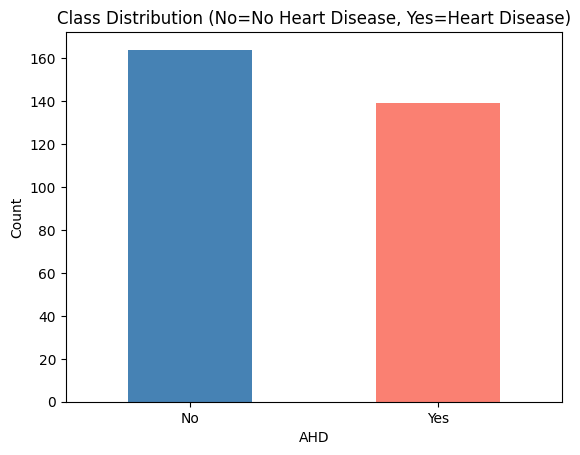

In [4]:
# Target distribution — how many with heart disease vs without?
print('Target (AHD) distribution:')
print(df['AHD'].value_counts())

df['AHD'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution (No=No Heart Disease, Yes=Heart Disease)')
plt.xlabel('AHD')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
# Q: Is the dataset balanced? If not, how will you handle it?

In [5]:
# Statistical summary of numeric columns
df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


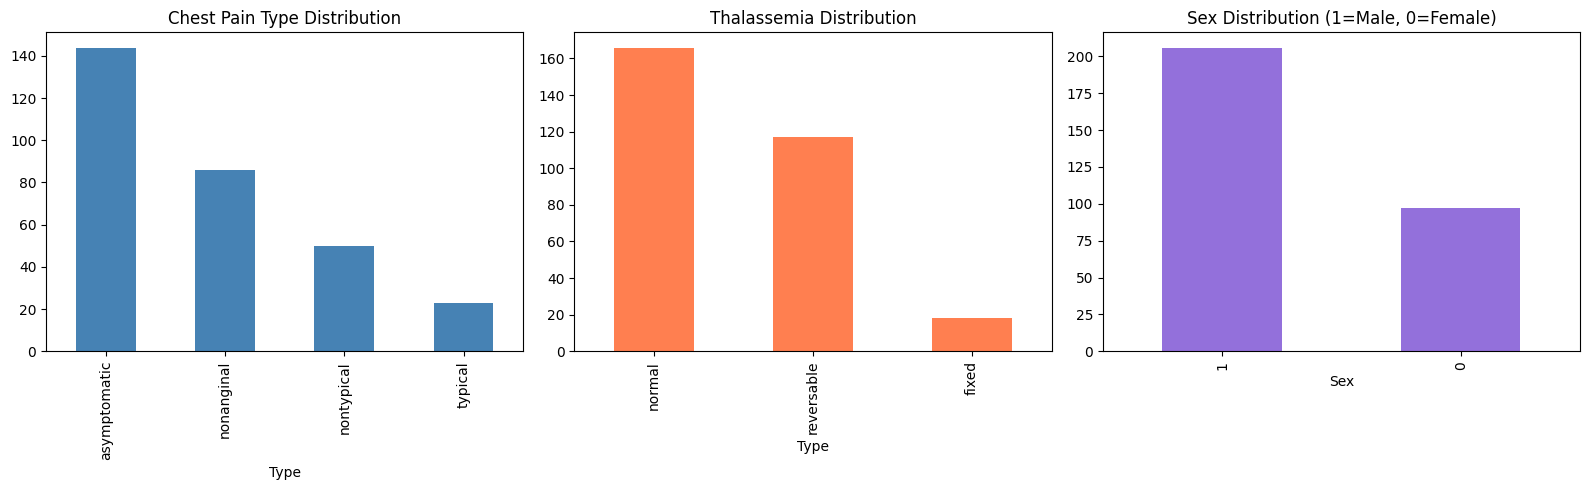

In [6]:
# Categorical feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ChestPain types
df['ChestPain'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Chest Pain Type Distribution')
axes[0].set_xlabel('Type')

# Thal types
df['Thal'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Thalassemia Distribution')
axes[1].set_xlabel('Type')

# Sex distribution
df['Sex'].value_counts().plot(kind='bar', ax=axes[2], color='mediumpurple')
axes[2].set_title('Sex Distribution (1=Male, 0=Female)')
axes[2].set_xlabel('Sex')

plt.tight_layout()
plt.show()

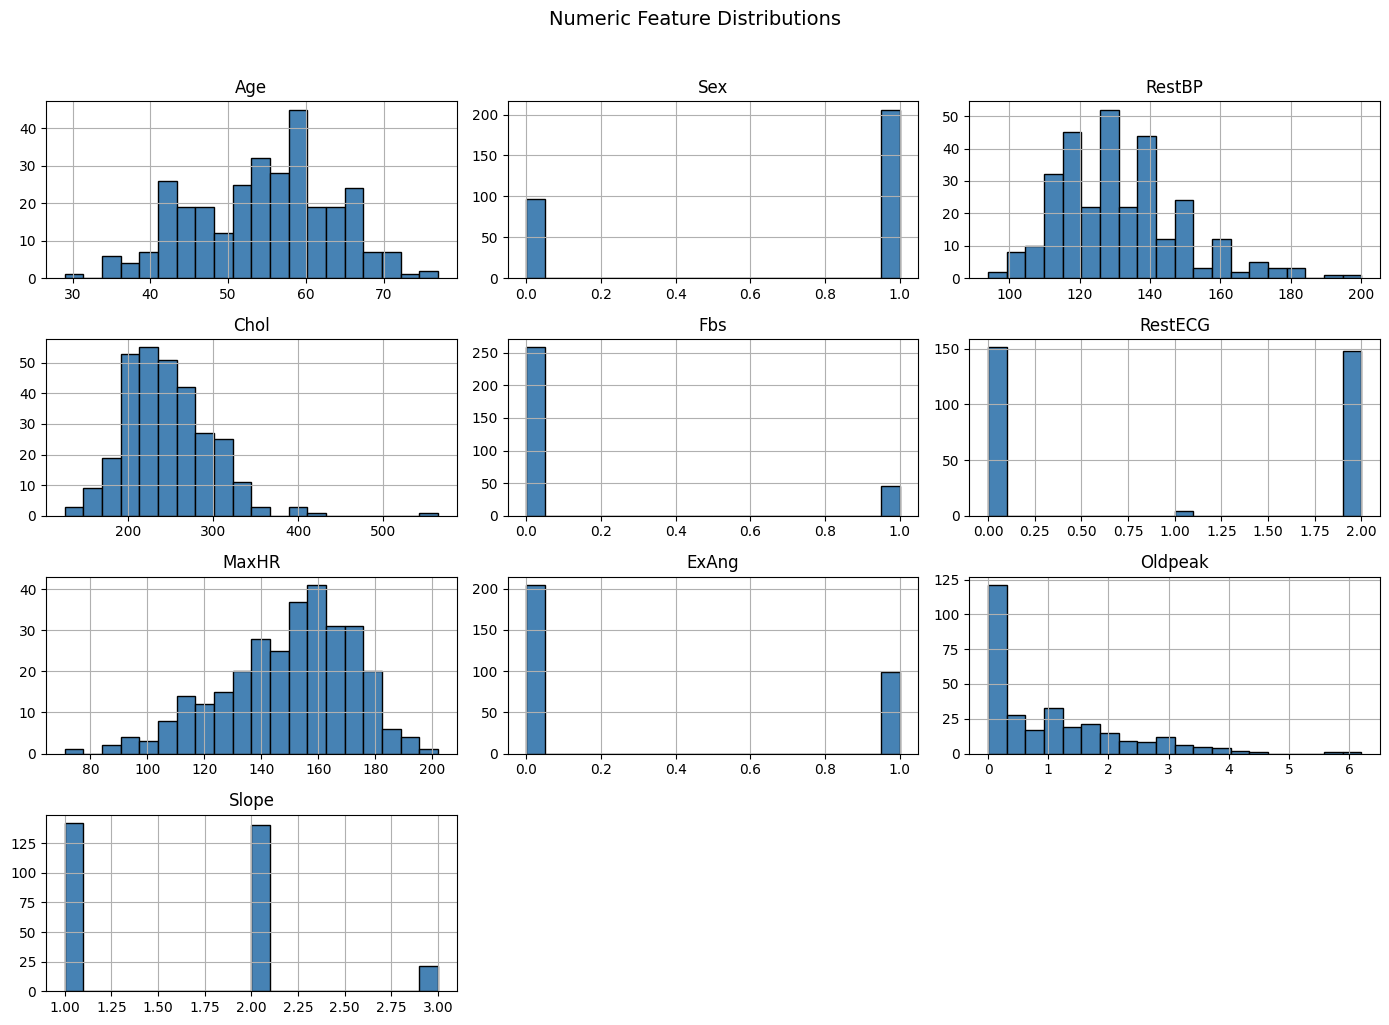

In [7]:
# Distribution of numeric features
numeric_cols = ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR',
                'ExAng', 'Oldpeak', 'Slope']
df[numeric_cols].hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('Numeric Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

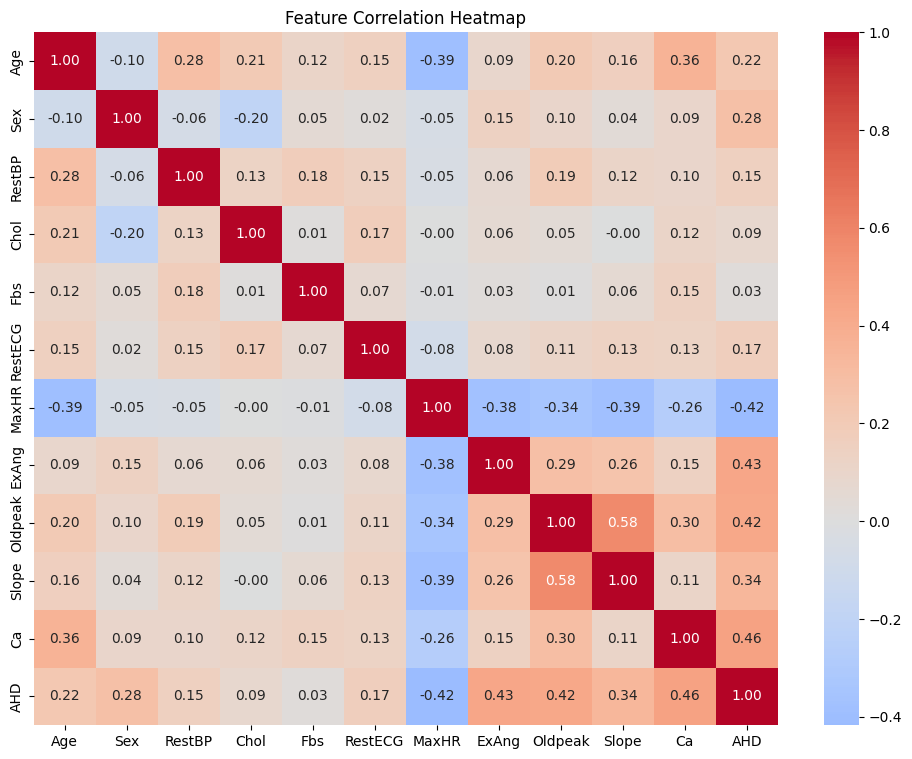

In [8]:
# Correlation heatmap (numeric columns only)
# First encode AHD for correlation
df_corr = df.copy()
df_corr['AHD'] = df_corr['AHD'].map({'Yes': 1, 'No': 0})
df_corr['Ca'] = pd.to_numeric(df_corr['Ca'], errors='coerce')
numeric_df = df_corr.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()
# Q: Which features are most correlated with AHD (last row)?

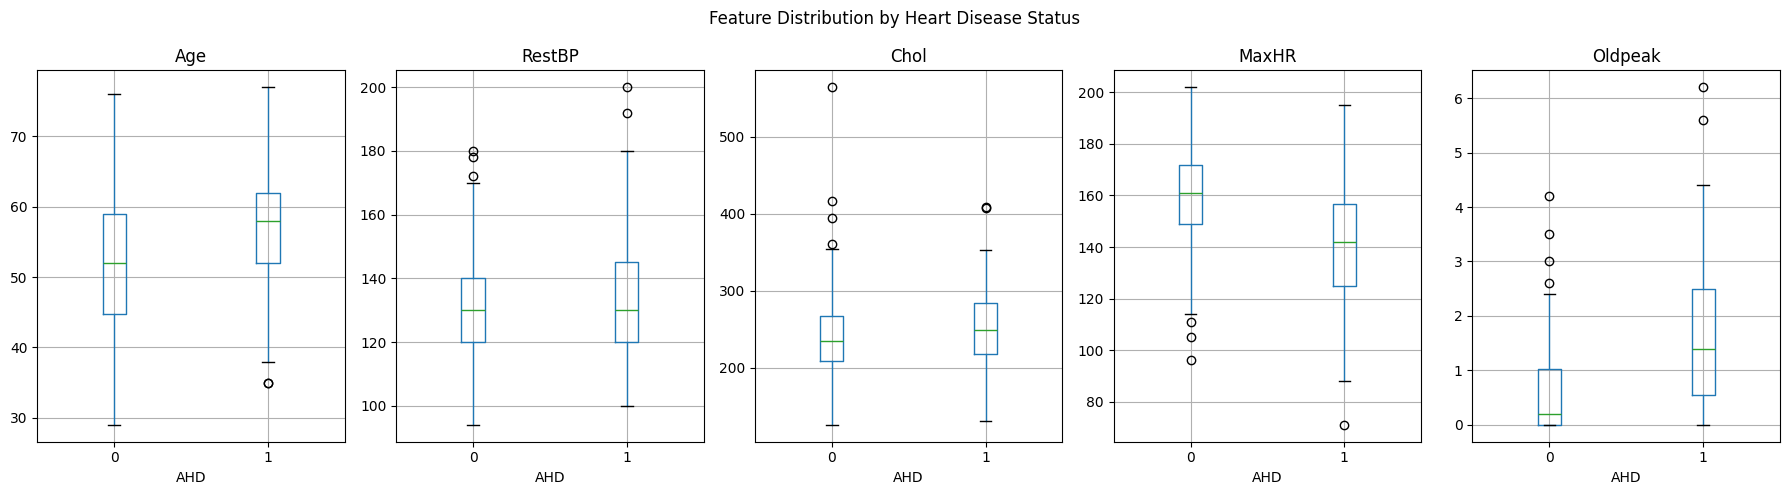

In [9]:
# Box plots — compare feature distributions for AHD=Yes vs AHD=No
features = ['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, feat in enumerate(features):
    df_corr.boxplot(column=feat, by='AHD', ax=axes[i])
    axes[i].set_title(feat)
plt.suptitle('Feature Distribution by Heart Disease Status')
plt.tight_layout()
plt.show()
# Q: Which features show the clearest separation between AHD=Yes and AHD=No?

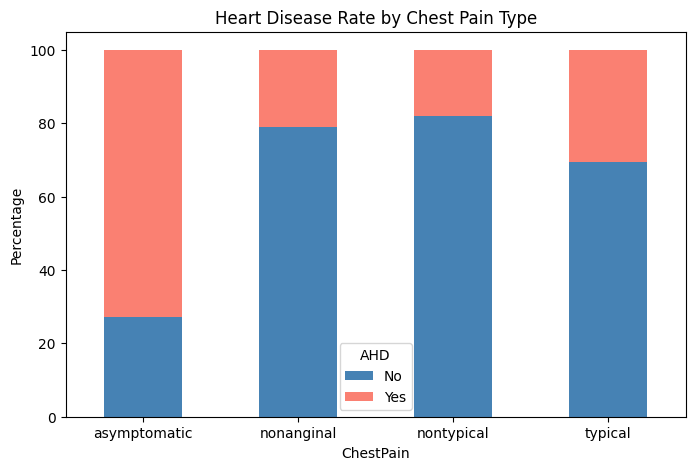

In [10]:
# Heart disease rate by chest pain type
ct = pd.crosstab(df['ChestPain'], df['AHD'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['steelblue', 'salmon'])
plt.title('Heart Disease Rate by Chest Pain Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='AHD')
plt.show()

## Your Observations
Write your findings here after running the cells above:

- Is the dataset balanced?
- Which features have missing/NA values?
- Which categorical features seem most predictive?
- Which numeric features show the clearest separation?
- Any surprising patterns?